In [1]:
from pepnets.PeptideNetwork import PeptideNetwork
import random
import pandas as pd
import numpy as np
from pepnets.util import get_database
import matplotlib.pyplot as plt
from pepnets.palette import group_palette, day_palette

random.seed(42)
np.random.seed(42)

sus_scrofa = pd.read_csv("../data/sus_scrofa.gz", sep="\t")
sus_scrofa["Entry Name"] = sus_scrofa["Entry Name"].apply(lambda x: x.split("_")[0])
database_dict = get_database(sus_scrofa, key_col="Entry Name", value_col="Sequence")
datamatrix = pd.read_csv("../data/data.csv")
pnet = PeptideNetwork(
    datamatrix=datamatrix,
    protein_database=database_dict,
)

/Users/erikhartman/dev/pepnets/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Reading peptides...


In [2]:
_ = pnet.create_network(distance_cutoff=4)
resolution = 0.8

clusters = pnet.get_clusters(resolution=resolution, random_seed=42)
clusters.merge_nearby_clusters(wiggle_room=2)
clusters.remove_small_clusters(threshold=3)
clusters.reindex()
mapping = clusters.get_mapping(database_dict)


Merged 41 clusters

Removed 0 clusters
Removed 857 clusters
Removed 303 clusters


In [ ]:
from pepnets.FeatureMatrix import FeatureMatrix

design = pd.read_csv("../data/design.csv")
fm = FeatureMatrix(pnet.datamatrix, design, clusters)
datamatrix = fm.get_normalized_dm()
topn = (
    fm.get_topn()
    .groupby("Cluster")
    .mean(numeric_only=True)
    .drop(columns=["id"])
)
topn = (
    topn.merge(mapping, left_index=True, right_on="ID_single")
    .rename(columns={"name_combined": "Cluster"})[
        ["Cluster"] + design["sample"].tolist()
    ]
    .drop_duplicates(subset="Cluster")
    .set_index("Cluster")
)


Clustering large matrix with scipy. Installing `fastcluster` may give better performance.


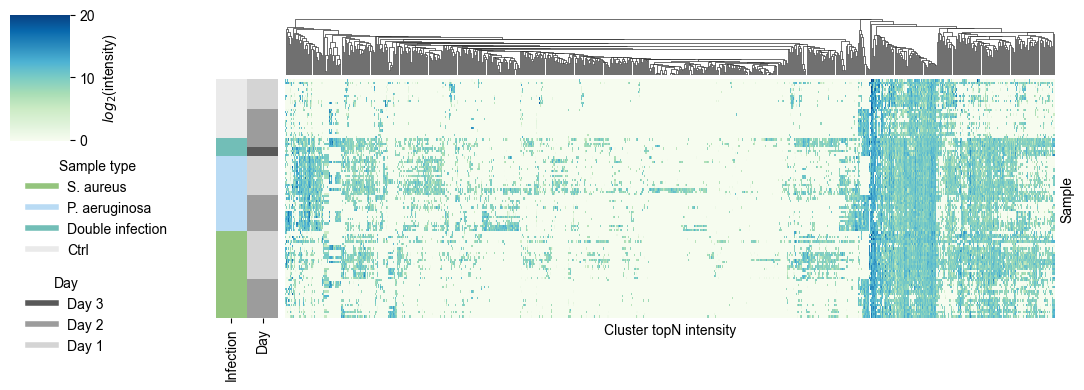

In [ ]:
import seaborn as sns
from matplotlib.lines import Line2D


design = design.sort_values(["group", "day"])
topn_heatmap = topn.fillna(0)[design["sample"]].T
group = pd.Series(design["group"])
day = pd.Series(design["day"])
group_colors = group.map(group_palette)
day_colors = day.map(day_palette)


g = sns.clustermap(
    topn_heatmap,
    row_cluster=False,
    row_colors=[group_colors.values, day_colors.values],
    cmap="GnBu",
    figsize=(12, 7),
    cbar_kws={"label": r"$log_2$(intensity)"},
    vmax=20,
)
g.ax_heatmap.tick_params(left=False, bottom=False, right=False)
g.ax_heatmap.set_xticks([])
g.ax_heatmap.set_yticks([])
g.ax_heatmap.set_xlabel("Cluster topN intensity")
g.ax_heatmap.set_ylabel("Sample")
g.ax_row_colors.set_xticks([0.5, 1.5], ["Infection", "Day"], rotation=90)

legend_elements = [
    Line2D([0], [0], color=c, lw=4, label=l)
    for l, c in zip(group_palette.keys(), group_palette.values())
]
days_elements = [
    Line2D([0], [0], color=c, lw=4, label=l)
    for l, c in zip(day_palette.keys(), day_palette.values())
]

legend_elements = legend_elements[:-1]
g.ax_row_dendrogram.remove()
g.ax_col_dendrogram.legend(
    frameon=False,
    handles=legend_elements,
    loc="upper left",
    bbox_to_anchor=(-0.35, -1.2),
    title="Sample type",
)
g.ax_heatmap.legend(
    frameon=False,
    handles=days_elements,
    loc="lower left",
    bbox_to_anchor=(-0.35, -0.2),
    title="Day",
)


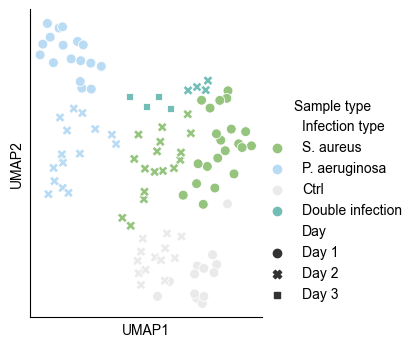

In [ ]:
from umap import UMAP
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt

design = pd.read_csv("../data/design.csv").reset_index()
samples = design["sample"]
feature_matrix = topn.T.loc[samples].fillna(0)
X = feature_matrix.values
scaler = StandardScaler()
X = scaler.fit_transform(X)
days = design["day"]
y = np.array(design["group"])

le = LabelEncoder()
y_int = le.fit_transform(y)

reducer = UMAP()
X_r = reducer.fit_transform(X)

df = pd.DataFrame(X_r)
df["Day"] = days
df["Infection type"] = y

fig = plt.figure(figsize=(3, 4))

sns.scatterplot(
    df, x=0, y=1, hue="Infection type", palette=group_palette, style="Day", s=50
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.xticks([])
plt.yticks([])
sns.despine()

plt.legend(
    loc="upper left", frameon=False, bbox_to_anchor=(0.95, 0.75), title="Sample type"
)


Mean of empty slice
Each of the input arrays is constant;the F statistic is not defined or infinite
Each of the input arrays is constant;the F statistic is not defined or infinite
Each of the input arrays is constant;the F statistic is not defined or infinite
Each of the input arrays is constant;the F statistic is not defined or infinite
Each of the input arrays is constant;the F statistic is not defined or infinite
Each of the input arrays is constant;the F statistic is not defined or infinite
invalid value encountered in double_scalars
invalid value encountered in double_scalars
This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


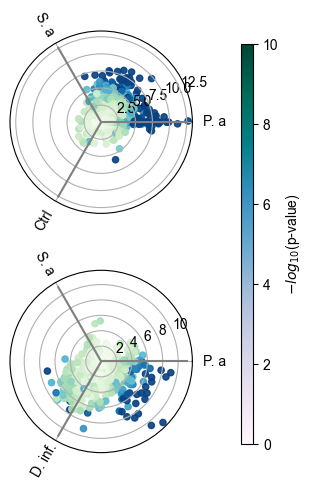

In [ ]:
import matplotlib
import numpy as np
from scipy.stats import f_oneway


def create_de(topn, design, groups, days):
    de_dict = {}
    design_day = design[design["day"].isin(days)]
    for group in groups:
        group_values = topn[design_day[design_day["group"] == group]["sample"]].T
        means = group_values.mean(axis=0).replace(np.nan, 0.01)
        de_dict["cluster"] = topn["Cluster"]
        de_dict[f"{group}"] = means
    anova = []
    for _, row in topn.iterrows():
        group_values = []
        for group in groups:
            row_values_for_group = row[
                design_day[design_day["group"] == group]["sample"]
            ].values.tolist()
            group_values.append(row_values_for_group)
        _, p = f_oneway(*group_values)
        anova.append(-np.log10(p))

    de_dict["anova"] = anova
    de = pd.DataFrame(de_dict).set_index("cluster")
    de.replace(np.inf, 10, inplace=True)
    de.replace(-np.inf, 10, inplace=True)
    de["sums"] = de.mean(axis=1)
    de.fillna(0, inplace=True)
    return de


def get_angle(a, b):
    if a <= 0:
        return np.pi + np.arctan(b / a)
    return np.arctan(b / a)


def get_complex(magnitude, angle):
    return magnitude * np.cos(angle) + magnitude * 1j * np.sin(angle)


def rotate_labels(y_offset):
    angles = np.linspace(0, 2 * np.pi, len(ax.get_xticklabels()) + 1)
    angles[np.cos(angles) < 0] = angles[np.cos(angles) < 0] + np.pi
    angles = np.rad2deg(angles)

    labels = []
    for label, angle in zip(ax.get_xticklabels(), angles):
        x, y = label.get_position()
        lab = ax.text(
            x,
            y - y_offset,
            label.get_text(),
            transform=label.get_transform(),
            ha=label.get_ha(),
            va=label.get_va(),
        )
        lab.set_rotation(angle)
        labels.append(lab)
    ax.set_xticklabels([])


def plot_polar(ax, de, groups, size=1, colors=None, cmap="coolwarm"):
    values = de[groups].values.T
    ngroups, npoints = values.shape
    thetas = [n * 2 * np.pi / ngroups for n in range(ngroups)]
    mags = []
    angles = []
    for point in range(npoints):
        vals = values[:, point]

        complexes = [get_complex(vals[i], thetas[i]) for i in range(ngroups)]
        real = sum([v.real for v in complexes])
        imag = sum([v.imag for v in complexes])
        mag = np.sqrt(real**2 + imag**2)
        angle = get_angle(real, imag)
        mags.append(mag)
        angles.append(angle)

    ax.scatter(angles, mags, s=size, c=colors, cmap=cmap, alpha=0.9)
    ax.vlines(thetas, 0, [max(mags)] * ngroups, color="gray")
    de["mag"] = mags
    de["angle"] = angles
    return de


topn_heatmap = (
    fm.get_topn()
    .groupby("Cluster")
    .mean(numeric_only=True)
    .drop(columns=["id", "Start", "End", "Cluster_start", "Cluster_end"])
)
topn_heatmap = (
    topn_heatmap.merge(mapping, left_index=True, right_on="ID_single")
    .rename(columns={"name_combined": "Cluster"})[
        ["Cluster"] + design["sample"].tolist()
    ]
    .drop_duplicates(subset="Cluster")
    .set_index("Cluster")
)
topn_heatmap = topn_heatmap[design["sample"]].fillna(0)
topn_heatmap.reset_index(inplace=True)


fig, axs = plt.subplots(2, 1, figsize=(4, 5), subplot_kw={"projection": "polar"})
groups1 = ["P. aeruginosa", "S. aureus", "Ctrl"]
days1 = ["Day 1", "Day 2"]
de1 = create_de(topn_heatmap, design, groups1, days1)
groups2 = ["P. aeruginosa", "S. aureus", "Double infection"]
days2 = ["Day 1", "Day 2", "Day 3"]
de2 = create_de(topn_heatmap, design, groups2, days2)
mags = plot_polar(
    axs[0], de1, groups1, size=20, cmap="GnBu", colors=de1["anova"].clip(0, 10)
)
mags2 = plot_polar(
    axs[1], de2, groups2, size=20, cmap="GnBu", colors=de2["anova"].clip(0, 10)
)
for ax, groups in zip(axs.ravel(), [groups1, groups2]):
    labels = ["D. inf." if item == "Double infection" else item for item in groups]
    labels = ["S. a" if item == "S. aureus" else item for item in labels]
    labels = ["P. a" if item == "P. aeruginosa" else item for item in labels]
    ax.set_xticks([2 * i * np.pi / len(labels) for i in range(len(labels))], labels)
    rotate_labels(y_offset=0.03)
    ax.set_xticklabels([])


ax = fig.add_axes([0.85, 0.1, 0.03, 0.8])
plt.colorbar(
    matplotlib.cm.ScalarMappable(
        norm=matplotlib.colors.Normalize(vmin=0, vmax=10), cmap="PuBuGn"
    ),
    cax=ax,
    label=r"$-log_{10}$(p-value)",
)

plt.tight_layout()
de1["upper/lower"] = "upper"
de2["upper/lower"] = "lower"


Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice


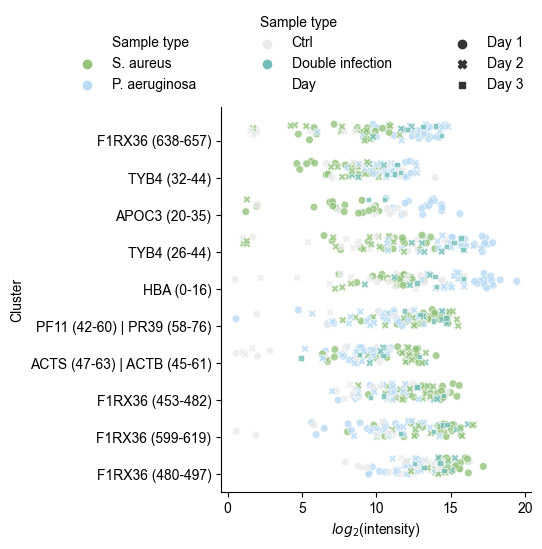

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dpks import QuantMatrix

topn_de = fm.get_topn_de(group_a="S. aureus", group_b="P. aeruginosa").set_index("Cluster")
topn_de = (
    topn_de.merge(mapping, left_index=True, right_on="ID_single")
    .rename(columns={"name_combined": "Cluster"})[
        ["Cluster"] + design["sample"].tolist()
    ]
    .drop_duplicates(subset="Cluster").reset_index()
)

qm = QuantMatrix(
    topn_de,
    design,
)
qm.compare(
    method="linregress",
    min_samples_per_group=15,
    level="Cluster",
    comparisons=[("P. aeruginosa", "S. aureus")],
    multiple_testing_correction_method="fdr_tsbh",
)

de = qm.to_df()

de = de.dropna(subset=["DEScoreP. aeruginosa-S. aureus"])
sa = de[de["Log2FoldChangeP. aeruginosa-S. aureus"] < 0].sort_values(
    ["-Log10CorrectedPValueP. aeruginosa-S. aureus"], ascending=False
)
pa = de[de["Log2FoldChangeP. aeruginosa-S. aureus"] > 0].sort_values(
    ["-Log10CorrectedPValueP. aeruginosa-S. aureus"], ascending=False
)
de = pd.concat([sa[:5], pa[:5]])

de = de.set_index("Cluster")[design["sample"]]
plot_df = de.stack().reset_index()
plot_df = plot_df.merge(design, left_on="level_1", right_on="sample")


plot_df.rename(columns={0: r"$log_2$(intensity)"}, inplace=True)
plot_df.replace(0, np.nan, inplace=True)




fig, ax = plt.subplots(1, 1, figsize=(4, 5))
mapper = {y:x for x, y in enumerate(plot_df["Cluster"].unique())}

plot_df["y"] = plot_df["Cluster"].map(mapper)
plot_df["y"] = plot_df["y"] + np.random.random(len(plot_df.index)) * 0.45
plot_df["Day"] = plot_df["day"]
plot_df["Sample type"] = plot_df["group"]

sns.scatterplot(
    data=plot_df,
    y="y",
    x="$log_2$(intensity)",
    hue="Sample type",
    palette=group_palette,
    s=30, 
    style="Day",
    alpha=.8
)

plt.yticks(list(mapper.values()), list(mapper.keys()))
plt.ylabel("Cluster")
plt.legend(
    bbox_to_anchor=(-0.5, 1.02, 1.5, 0.05),
    ncols=3,
    mode="expand",
    borderaxespad=0.1,
    title="Sample type",
    frameon=False,
)
sns.despine()

In [ ]:
design = pd.read_csv("../data/design.csv")
topn_de = fm.get_topn_de(group_a="S. aureus", group_b="P. aeruginosa")
qm = QuantMatrix(
    topn_de,
    design,
)
qm.compare(
    method="linregress",
    min_samples_per_group=3,
    level="Cluster",
    comparisons=[("P. aeruginosa", "S. aureus")],
    multiple_testing_correction_method="fdr_tsbh",
)

de = qm.to_df()
de = de[de["Log2FoldChangeP. aeruginosa-S. aureus"] > 2]
de = de[de["CorrectedPValueP. aeruginosa-S. aureus"] < 0.05]
de.sort_values("CorrectedPValueP. aeruginosa-S. aureus")

Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice


,Cluster,DEScoreP. aeruginosa-S. aureus,GroupP. aeruginosaMean,GroupS. aureusMean,GroupP. aeruginosaStdev,GroupS. aureusStdev,Log2FoldChangeP. aeruginosa-S. aureus,PValueP. aeruginosa-S. aureus,GroupP. aeruginosaRepCounts,GroupS. aureusRepCounts,...,Sample 57 Day 2,Sample 66 Day 2,Sample 67 Day 2,Sample 68 Day 2,Sample 69 Day 2,Sample 70 Day 2,Sample 54 Day 3,Sample 55 Day 3,Sample 56 Day 3,Sample 57 Day 3
18,HBA_1,1.256484,16.181039,10.738981,1.453170,1.648764,5.442058,2.423457e-18,33,24,...,9.229620,NaN,NaN,NaN,NaN,8.300798,14.029988,15.860671,13.959336,12.739638
106,TYB4_3,0.973133,15.248618,9.765639,1.935667,3.337044,5.482979,2.741619e-11,33,33,...,13.237513,1.296913,7.276319,9.665919,1.283119,11.864991,15.696176,15.837461,15.239597,14.702888
362,TYB10_2,1.144814,13.578848,6.425373,1.490225,4.127541,7.153474,1.522656e-10,33,12,...,9.636682,NaN,NaN,0.537254,NaN,8.703664,15.098955,9.866496,12.627510,10.776020
6,F1RX36_33,0.826458,12.704451,8.249227,1.879498,2.613406,4.455225,2.691139e-10,33,28,...,11.669532,NaN,4.240132,9.220707,NaN,7.696170,14.368023,13.139984,13.985591,12.083277
105,TYB4_4,0.654130,10.802552,8.114744,1.167538,1.626268,2.687808,3.695749e-10,33,30,...,9.532368,6.972179,7.710077,8.360154,NaN,9.386756,11.385942,10.690387,11.628085,11.205622
32,APOC3_0,0.973214,13.219611,7.103953,1.272000,2.858667,6.115659,6.429889e-09,17,17,...,NaN,1.296913,NaN,NaN,NaN,NaN,9.477878,10.532538,NaN,NaN
145,HMGN2_2,1.030019,10.362970,3.718909,3.056235,3.644616,6.644061,1.431521e-08,33,18,...,8.646319,NaN,NaN,0.537254,NaN,0.740740,12.743475,12.017989,10.024422,6.607337
150,F1RX36_23,0.895335,13.102483,7.535005,2.454955,3.277692,5.567478,1.597590e-08,32,19,...,10.696909,1.296913,8.860547,7.540818,NaN,9.408161,13.987526,13.852556,13.466390,11.619371
359,H1T_3,0.922993,10.738538,4.622862,3.083469,3.604826,6.115677,7.444984e-07,30,15,...,10.019860,NaN,NaN,0.537254,NaN,0.740740,12.217209,14.209257,6.688465,4.675179
251,APOA1_10,0.546176,11.432214,8.170757,1.176064,1.967788,3.261457,5.040202e-06,20,11,...,NaN,NaN,NaN,NaN,NaN,NaN,9.411899,9.466396,NaN,NaN


Mean of empty slice
invalid value encountered in true_divide
invalid value encountered in true_divide
invalid value encountered in true_divide


0.91 accuracy with a standard deviation of 0.02


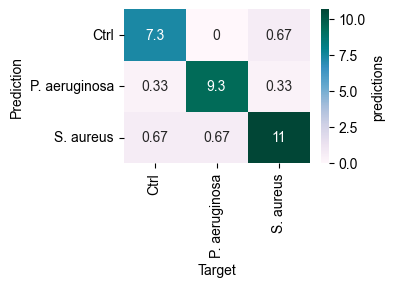

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score
import xgboost
from sklearn.metrics import confusion_matrix


topn = (
    fm.get_topn()
    .groupby("Cluster")
    .mean(numeric_only=True)
    .drop(columns=["id", "Start", "End", "Cluster_start", "Cluster_end"])
)
topn = (
    topn.merge(mapping, left_index=True, right_on="ID_single")
    .rename(columns={"name_combined": "Cluster"})[
        ["Cluster"] + design["sample"].tolist()
    ]
    .drop_duplicates(subset="Cluster")
)
groups = ["Ctrl", "S. aureus", "P. aeruginosa"]
design = pd.read_csv("../data/design_w_accidental.csv")
design = design[design["group"].isin(groups)].reset_index()
clf_xgb = xgboost.XGBClassifier(random_state=1337)
X = topn[design["sample"]].values.T
scaler = StandardScaler()
X = scaler.fit_transform(X)
y = np.array(design["group"])
le = LabelEncoder()
y_int = le.fit_transform(y)


def cross_val(clf, X, y):

    cv = StratifiedShuffleSplit(n_splits=3, test_size=0.3)
    scores = []
    cf = []
    for train_index, test_index in cv.split(X, y):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y_int[train_index], y_int[test_index]
        clf.fit(X_train, y_train)

        pred = clf_xgb.predict(X_test)
        cf.append(confusion_matrix(y_test, pred))
        scores.append(accuracy_score(y_test, pred))
    scores = np.array(scores)
    return scores, cf
    # get accuracy of each prediction


scores, cf = cross_val(clf_xgb, X, y)
print(
    "%0.2f accuracy with a standard deviation of %0.2f" % (scores.mean(), scores.std())
)
cf = np.array(cf).mean(axis=0)
plt.figure(figsize=(3, 2))
sns.heatmap(
    cf,
    annot=True,
    cmap="PuBuGn",
    cbar_kws={"label": "predictions"},
    xticklabels=le.classes_,
    yticklabels=le.classes_,
)
plt.xlabel("Target")
plt.ylabel("Prediction")

747


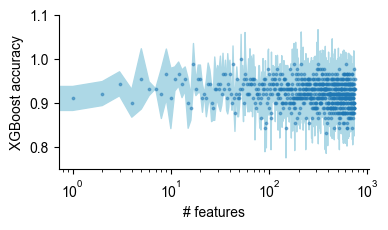

In [ ]:
import shap
import numpy as np

mean_scores = []
std_scores = []

importances = []
bottom_features = []

X_subset = X
features = feature_matrix.columns.values
n_samples, n_features = X.shape
print(n_features)

for n in range(n_features - 1):
    clf = xgboost.XGBClassifier(random_state=42)
    scores, cf = cross_val(clf_xgb, X_subset, y_int)
    mean_scores.append(np.mean(scores))
    std_scores.append(np.std(scores))
    clf = clf.fit(X_subset, y_int)
    explainer = shap.TreeExplainer(clf, X_subset, feature_names=features)
    shap_values = explainer.shap_values(X_subset, y_int)
    shaps = np.sum(np.mean(np.abs(shap_values), axis=1), axis=0)
    argmin = np.argmin(shaps)
    importances.append(shaps[argmin])
    bottom_features.append(features[argmin])
    features = np.delete(features, argmin)
    X_subset = np.delete(X_subset, argmin, axis=1)

mean_scores = mean_scores[::-1]
plt.figure(figsize=(4, 2))
plt.fill_between(
    range(len(mean_scores)),
    np.array(mean_scores) - np.array(std_scores),
    np.array(mean_scores) + np.array(std_scores),
    color="lightblue",
)
plt.scatter(x=range(len(mean_scores)), y=mean_scores, alpha=0.5, s=3)
plt.xlabel("# features")
plt.ylabel("XGBoost accuracy")
plt.xscale("log")
sns.despine()
plt.ylim([0.75, 1.1])

feature_importances = pd.DataFrame(
    {
        "feature": bottom_features,
        "rank": list(range(len(bottom_features)))[::-1],
        "mean_score": mean_scores,
        "std_score": std_scores,
    }
)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

design = pd.read_csv("../data/design_w_accidental.csv")

topn = (
    fm.get_topn()
    .groupby("Cluster")
    .mean(numeric_only=True)
    .drop(columns=["id", "Start", "End", "Cluster_start", "Cluster_end"])
).fillna(0)
topn = (
    topn.merge(mapping, left_index=True, right_on="ID_single")
    .rename(columns={"name_combined": "Cluster"})[
        ["Cluster"] + design["sample"].tolist()
    ]
    .drop_duplicates(subset="Cluster")
).set_index("Cluster")

training_groups = ["S. aureus", "P. aeruginosa"]
testing_groups = ["Double infection"]


training_samples = design[design["group"].isin(training_groups)]["sample"]
testing_samples = design[design["group"].isin(testing_groups)]["sample"]

X = topn.T.values

scaler = StandardScaler()

X = scaler.fit_transform(X)

topn = pd.DataFrame(X, columns=topn.index, index=topn.columns)

X_train = topn.loc[training_samples]
X_test = topn.loc[testing_samples]
y_train = np.array(design[design["group"].isin(training_groups)]["group"])
le = LabelEncoder()
y_int = le.fit_transform(y_train)
days = design[design["group"].isin(testing_groups)]["day"]

y_int

Mean of empty slice


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1])

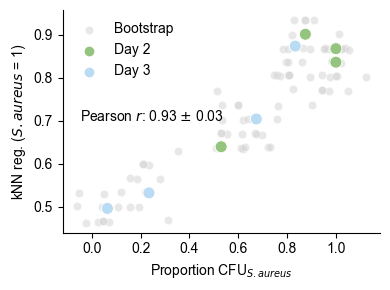

In [ ]:
cfu = pd.read_excel("../data/raw/cfu.xlsx")
di = cfu[cfu["group"] == "Double infection"].copy()

di["sa"] = di["swab av sa"] * di["dilution sa"]
di["pa"] = di["swab av pa"] * di["dilution pa"]

di = di[di["day"].isin([2, 3])]
di["day"] = di["day"].apply(lambda x: "Day " + str(x))
di = di[["sample", "day", "sa", "pa"]]


from sklearn.neighbors import KNeighborsRegressor

fig = plt.figure(figsize=(4, 3))
ax = plt.gca()
rs = []
for i in range(10):
    np.random.seed(i)
    X_train = topn.loc[training_samples]
    X_test = topn.loc[testing_samples]
    di["pa/sa"] = di["sa"] / (di["pa"] + di["sa"])
    di["pa/sa"] = di["pa/sa"] + (np.random.normal(size=len(di.index))) * 0.05
    X_train = X_train + (np.random.normal(scale=1, size=X_train.shape))
    neigh = KNeighborsRegressor(n_neighbors=30, weights="distance")
    neigh.fit(X_train, y_int)
    pa_over_sa = neigh.predict(X_test)
    di["prob_pa"] = pa_over_sa
    r = np.corrcoef(di["pa/sa"], di["prob_pa"])[0, 1]
    rs.append(r)
    sns.scatterplot(
        di, x="pa/sa", y="prob_pa", color="lightgray", alpha=0.5, legend=None, ax=ax
    )
sns.scatterplot(
    di,
    x="pa/sa",
    y="prob_pa",
    color="lightgray",
    alpha=0.5,
    label="Bootstrap",
    ax=ax,
)
X_train = topn.loc[training_samples]
X_test = topn.loc[testing_samples]
di["pa/sa"] = di["sa"] / (di["pa"] + di["sa"])
neigh = KNeighborsRegressor(n_neighbors=30, weights="distance")
neigh.fit(X_train, y_int)
pa_over_sa = neigh.predict(X_test)
di["prob_pa"] = pa_over_sa
sns.scatterplot(
    di,
    x="pa/sa",
    y="prob_pa",
    hue="day",
    palette=[group_palette["S. aureus"], group_palette["P. aeruginosa"]],
    ax=ax,
    s=75,
)

r = np.corrcoef(di["pa/sa"], di["prob_pa"])[0, 1]
rs.append(r)

sns.despine()
plt.xlabel(r"Proportion CFU$_{S. aureus} $")
plt.ylabel(r"kNN reg. ($S. aureus$ = 1)")
plt.text(-0.05, 0.7, rf"Pearson $r$: {np.mean(rs):.2f} $\pm$ {np.std(rs):.2f}")
plt.legend(frameon=False, loc="upper left")
plt.tight_layout()
